In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, date, timedelta
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors

VEOLIA, SUNRUN, SOLAREDGE. CASH COLLECT CALLABLE

In [2]:
# PREZZO CERTIFICATE
prezzo = 628.5

In [3]:
# DATI PANIERE

yf.set_tz_cache_location("C:/yf_cache")

tickers = ["VIE.PA","RUN","SEDG"]
dati = yf.download(tickers, period="max", auto_adjust=False)["Close"]
dati.dropna(inplace=True)
dati = dati.reindex(pd.date_range(str(dati.index[0]), str(dati.index[-1])), method="ffill")

[*********************100%***********************]  3 of 3 completed


In [4]:
dati.head(30)

Ticker,RUN,SEDG,VIE.PA
2015-08-05,10.77,30.750000,20.295807
2015-08-06,8.77,27.400000,20.363298
2015-08-07,10.14,28.590000,20.001736
2015-08-08,10.14,28.590000,20.001736
2015-08-09,10.14,28.590000,20.001736
2015-08-10,10.12,27.830000,20.271704
2015-08-11,9.79,28.000000,20.131899
2015-08-12,10.35,30.299999,19.466619
2015-08-13,10.12,27.260000,19.794437
2015-08-14,10.04,27.280001,19.702843


<Axes: >

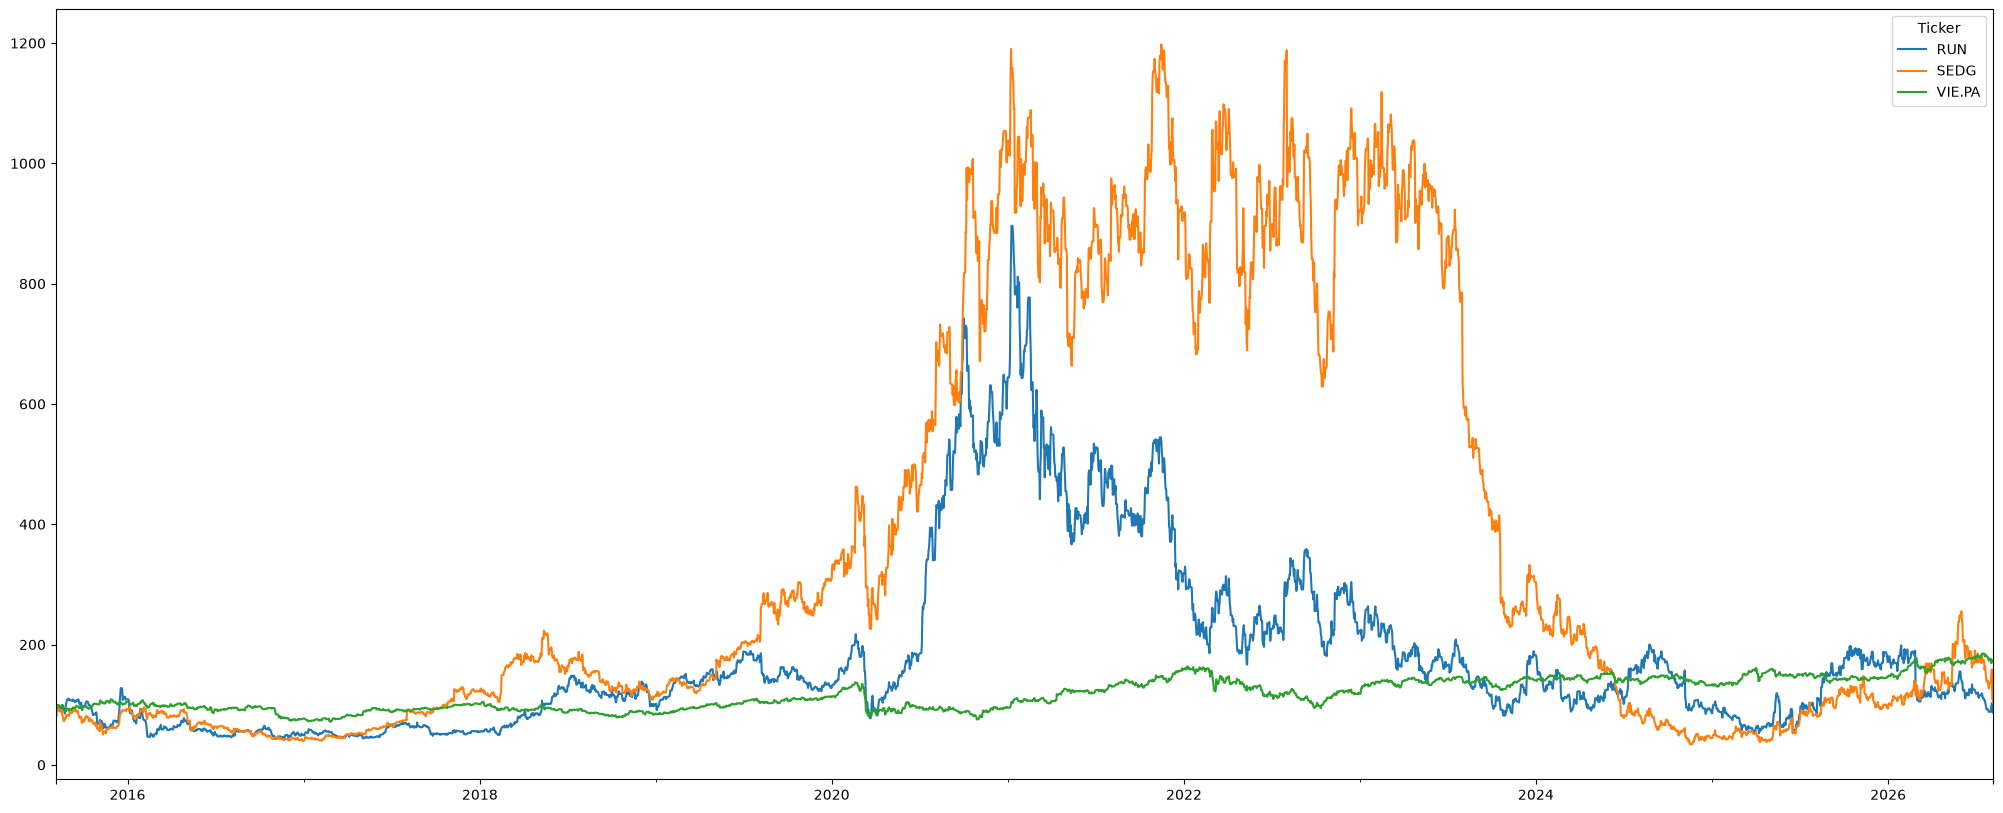

In [5]:
(100*dati/dati.iloc[0]).plot(figsize=(25,10))

In [6]:
rimborso = 1000
fixing = dict(zip(tickers, [29.25,16.98,83.3]))
barriere = dict(zip(tickers, [10.2375,5.943,29.155]))
date_rimborso_anticipato = [
                datetime.strptime("21.08.2026", '%d.%m.%Y').date(),
                datetime.strptime("23.09.2026", '%d.%m.%Y').date(),
                datetime.strptime("21.10.2026", '%d.%m.%Y').date(),
                datetime.strptime("23.11.2026", '%d.%m.%Y').date(),
                datetime.strptime("23.12.2026", '%d.%m.%Y').date(),
                datetime.strptime("21.01.2027", '%d.%m.%Y').date()
                ]
fine = datetime.strptime("23.02.2027", '%d.%m.%Y').date()

In [7]:
#PREMIO MENSILE
premio_importo = rimborso * 0.0140

date_premi = [datetime.strptime(d, "%d.%m.%Y").date() for d in
    ["21.08.2026","23.09.2026","21.10.2026","23.11.2026","23.12.2026","21.01.2027","23.02.2027"]]
premio_importo = rimborso * 0.0140

def premi_incassati(data_rimborso):
    return sum(1 for d in date_premi if d <= data_rimborso) * premio_importo


In [8]:
giorni_durata = (fine - datetime.today().date()).days   # positivo

# cattura il prezzo VERO di oggi, prima del dropna
spot = {t: dati[t].iloc[-1] for t in tickers}

for t in tickers:
    dati["finale_"+t] = dati[t].shift(-giorni_durata)/dati[t] - 1

dati.dropna(inplace=True)
print(spot)

{'VIE.PA': np.float64(35.189998626708984), 'RUN': np.float64(10.305000305175781), 'SEDG': np.float64(31.6299991607666)}


In [9]:
dati

Ticker,RUN,SEDG,VIE.PA,finale_VIE.PA,finale_RUN,finale_SEDG
2015-08-05,10.77,30.75,20.295807,0.012589,-0.497679,-0.174634
2015-08-06,8.77,27.40,20.363298,0.028172,-0.423033,-0.120803
2015-08-07,10.14,28.59,20.001736,0.045071,-0.491124,-0.155299
2015-08-08,10.14,28.59,20.001736,0.020969,-0.500986,-0.129066
2015-08-09,10.14,28.59,20.001736,0.032538,-0.477318,-0.118923
...,...,...,...,...,...,...
2026-01-15,18.26,33.84,29.840000,0.149464,-0.428806,0.333333
2026-01-16,18.23,33.91,29.820000,0.173038,-0.394953,0.437924
2026-01-17,18.23,33.91,29.820000,0.183434,-0.424575,-0.000295
2026-01-18,18.23,33.91,29.820000,0.176056,-0.485464,-0.036567


In [10]:
conto_non_normalizzato = False

rendimenti = []
for giorno in range(len(dati)):
    worst = min(spot[t]*(1+dati["finale_"+t].iloc[giorno])/fixing[t] for t in tickers)
    capitale = rimborso*worst if worst < 0.35 else rimborso   # evento barriera vs nozionale pieno
    incasso = capitale + premi_incassati(fine)

    if conto_non_normalizzato:
        rendimenti.append(incasso)
    else:
        rendimenti.append((incasso/prezzo)**(365.24/giorni_durata) - 1)

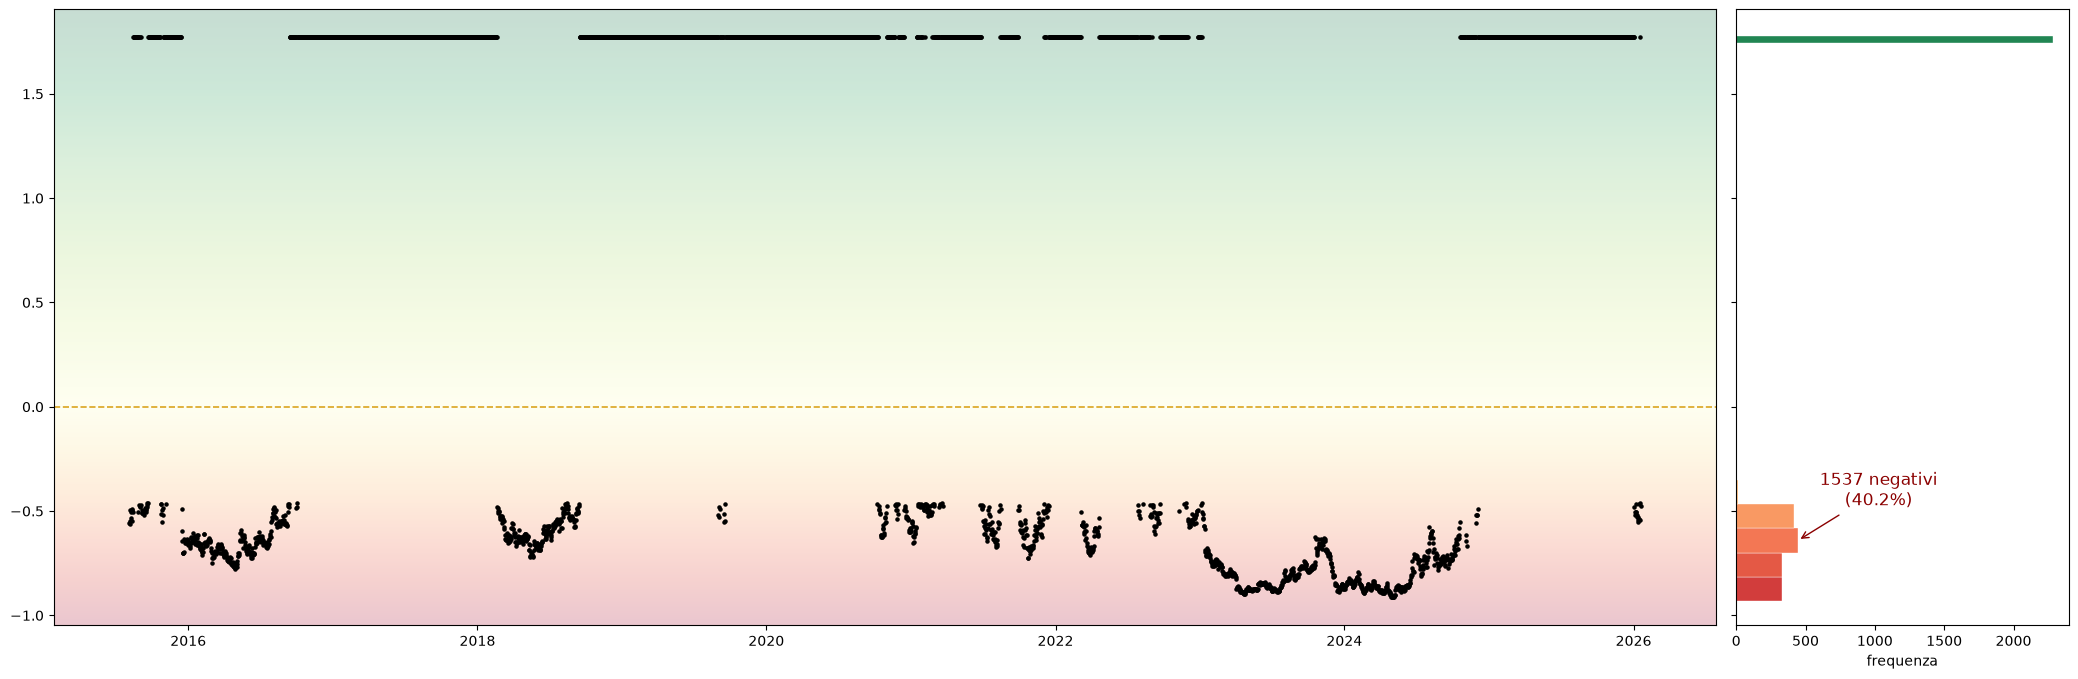

In [11]:
s = pd.Series(rendimenti, index=dati.index)
center = prezzo if conto_non_normalizzato else 0.0

ymin, ymax = s.min(), s.max()
pad = (ymax - ymin) * 0.05
ymin -= pad; ymax += pad
norm = mcolors.TwoSlopeNorm(vmin=ymin, vcenter=center, vmax=ymax)
cmap = plt.get_cmap("RdYlGn")

fig, (ax, axh) = plt.subplots(1, 2, figsize=(26, 8), sharey=True,
                              gridspec_kw={"width_ratios": [5, 1], "wspace": 0.02})

# --- scatter + sfondo semaforo ---
ax.scatter(s.index, s.values, s=5, c="black", zorder=2)
x0, x1 = ax.get_xlim()
ax.imshow(np.linspace(ymax, ymin, 256).reshape(-1, 1), extent=[x0, x1, ymin, ymax],
          aspect="auto", cmap=cmap, norm=norm, alpha=0.22, zorder=0)
ax.axhline(center, color="goldenrod", lw=1.2, ls="--", zorder=1)
ax.set_xlim(x0, x1); ax.set_ylim(ymin, ymax)

# --- istogramma: bin larghi sotto il centro, fitti sopra ---
edges = np.concatenate([np.linspace(ymin, center, 10),      # ~9 bin larghi (perdite)
                        np.linspace(center, ymax, 60)[1:]]) # bin fitti (parte positiva)
counts, edges = np.histogram(s.values, bins=edges)
centers = (edges[:-1] + edges[1:]) / 2
widths = np.diff(edges)
axh.barh(centers, counts, height=widths, color=cmap(norm(centers)),
         alpha=0.9, edgecolor="white", linewidth=0.3)
axh.set_xlabel("frequenza")
axh.tick_params(labelleft=False)

# --- freccina col conteggio dei negativi ---
neg = centers < center
n_neg = int(counts[neg].sum())
pct = n_neg / len(s) * 100
y_neg = centers[neg][np.argmax(counts[neg])]
x_neg = counts[neg].max()
axh.annotate(f"{n_neg} negativi\n({pct:.1f}%)",
             xy=(x_neg, y_neg),                                   
             xytext=(counts.max() * 0.45, center - (center - ymin) * 0.45),  
             ha="center", fontsize=12, color="darkred",
             arrowprops=dict(arrowstyle="->", color="darkred"))

plt.show()

In [12]:
pd.Series(rendimenti,index=dati.index).describe()

count    3821.000000
mean        0.784552
std         1.204271
min        -0.914257
25%        -0.627451
50%         1.770020
75%         1.770020
max         1.770020
dtype: float64

## Valutazione tramite Certainty Equivalent (utilità CRRA)

**Equivalente certo** — importo certo che rende indifferente al possesso dello strumento rischioso:

$$\text{CE} = u^{-1}\big(\mathbb{E}[u(X)]\big), \qquad u(x) = \frac{x^{1-\gamma}}{1-\gamma}$$

Sulla distribuzione empirica dei payoff $\{x_i\}_{i=1}^{N}$:

$$\text{CE}(\gamma) = \left(\frac{1}{N}\sum_{i=1}^{N} x_i^{\,1-\gamma}\right)^{\frac{1}{1-\gamma}} \quad (\gamma \neq 1), \qquad \text{CE}(1) = \exp\!\left(\frac{1}{N}\sum_{i=1}^{N} \ln x_i\right)$$

**Valore oggi** (scontato al tasso risk-free $r$ su orizzonte $T$):

$$V(\gamma) = e^{-rT}\,\text{CE}(\gamma)$$

**Casi particolari e interpretazione:**

- $\gamma = 0$ (neutrale al rischio): $\text{CE} = \frac{1}{N}\sum_i x_i = \mathbb{E}[X]$, cioè la sola media → $V = e^{-rT}\,\mathbb{E}[X]$.
- $\gamma > 0$: la concavità di $u$ penalizza la coda sinistra; più alto è $\gamma$, più $\text{CE}$ scende sotto la media.
- **Premio per il rischio:** $\ \pi(\gamma) = \mathbb{E}[X] - \text{CE}(\gamma)$
- **Regola di decisione:** $\ V(\gamma) > \text{prezzo} \Rightarrow$ conviene; $\ V(\gamma) < \text{prezzo} \Rightarrow$ paghi troppo per quel rischio.

## Come interpretare γ: il test della scommessa 50/50

Per dare un significato concreto a γ, traducilo in una scommessa: **50/50 — o raddoppi il capitale, o ne perdi una frazione L**. La massima perdita L che accetteresti individua la tua avversione al rischio.

Condizione di indifferenza (utilità CRRA):

$$0.5 \cdot 2^{\,1-\gamma} + 0.5 \cdot (1-L)^{\,1-\gamma} = 1$$

| γ | Max perdita L accettata per un 50/50 di raddoppiare | Profilo |
|---|---|---|
| 0,5 | 66% | molto aggressivo |
| 1 | 50% | aggressivo (log / Kelly) |
| 2 | 33% | moderato |
| 3 | 24% | moderato-prudente |
| 5 | 15% | prudente |
| 10 | 7% | molto prudente |
| 20 | 4% | avversissimo |

**Lettura:** se pur di avere il 50% di probabilità di raddoppiare accetti di rischiare di perdere metà del capitale → γ ≈ 1; se il massimo che tolleri è −15% → γ ≈ 5.

**Riferimenti empirici:** investitore individuale tipico γ ≈ 2–4; profili prudenti γ ≈ 5–10; fascia realistica complessiva 1–10 (default ragionevole 2–4).

In [13]:
conto_non_normalizzato = True

rendimenti = []
for giorno in range(len(dati)):
    worst = min(spot[t]*(1+dati["finale_"+t].iloc[giorno])/fixing[t] for t in tickers)
    capitale = rimborso*worst if worst < 0.35 else rimborso   # evento barriera vs nozionale pieno
    incasso = capitale + premi_incassati(fine)

    if conto_non_normalizzato:
        rendimenti.append(incasso)
    else:
        rendimenti.append((incasso/prezzo)**(365.24/giorni_durata) - 1)

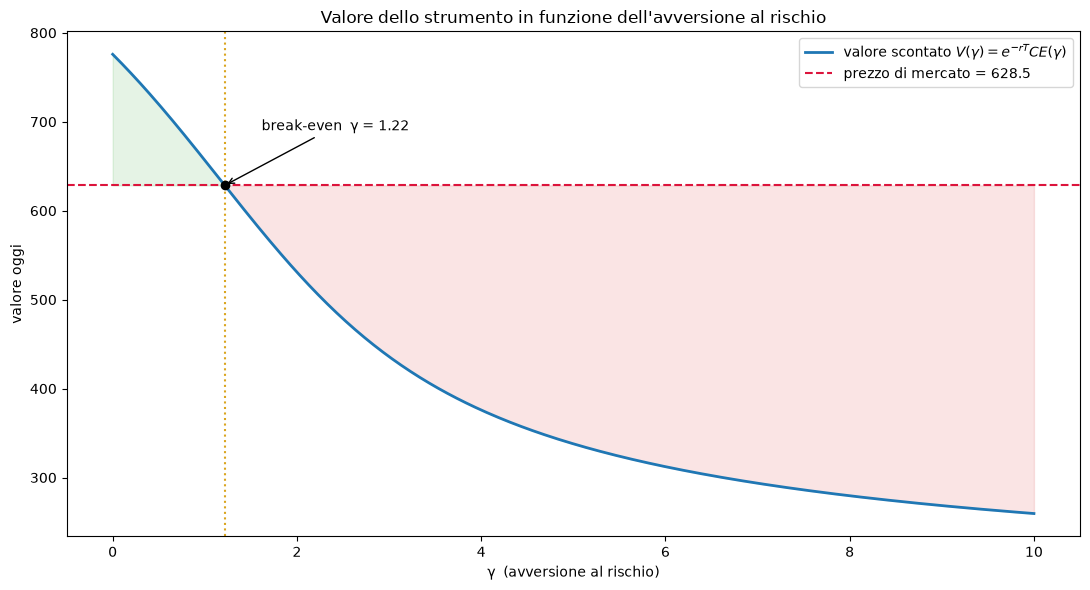

In [14]:
X = np.array(rendimenti, dtype=float)      # richiede conto_non_normalizzato = True
r = 0.03
T = giorni_durata / 365.24
disc = np.exp(-r*T)

def V(g):                                  # valore scontato al variare di gamma
    ce = np.exp(np.mean(np.log(X))) if abs(g-1) < 1e-9 else np.mean(X**(1-g))**(1/(1-g))
    return disc * ce

gammas = np.linspace(0, 10, 400)
vals = np.array([V(g) for g in gammas])

# gamma di break-even: dove la curva incrocia il prezzo
gamma_be = None
sign = np.sign(vals - prezzo)
idx = np.where(np.diff(sign) != 0)[0]
if len(idx):
    i = idx[0]; g0, g1 = gammas[i], gammas[i+1]; v0, v1 = vals[i], vals[i+1]
    gamma_be = g0 + (prezzo - v0) * (g1 - g0) / (v1 - v0)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(gammas, vals, lw=2, color="tab:blue", label=r"valore scontato $V(\gamma)=e^{-rT}CE(\gamma)$")
ax.axhline(prezzo, color="crimson", ls="--", lw=1.5, label=f"prezzo di mercato = {prezzo:.1f}")

# zone conviene (verde) / non conviene (rosso)
ax.fill_between(gammas, vals, prezzo, where=(vals >= prezzo), color="tab:green", alpha=0.12)
ax.fill_between(gammas, vals, prezzo, where=(vals <  prezzo), color="tab:red",   alpha=0.12)

if gamma_be is not None:
    ax.axvline(gamma_be, color="goldenrod", ls=":", lw=1.5)
    ax.plot(gamma_be, prezzo, "o", color="black", zorder=5)
    ax.annotate(f"break-even  γ = {gamma_be:.2f}",
                xy=(gamma_be, prezzo),
                xytext=(gamma_be + 0.4, prezzo + (vals.max()-vals.min())*0.12),
                arrowprops=dict(arrowstyle="->"))

ax.set_xlabel("γ  (avversione al rischio)")
ax.set_ylabel("valore oggi")
ax.set_title("Valore dello strumento in funzione dell'avversione al rischio")
ax.legend()
plt.tight_layout()
plt.show()